# **Graphs - Traversal and Path Finding**

In [75]:
# !pip install networkx        # install only once

In [76]:
import networkx as nx
import matplotlib.pyplot as plt

# for notebook 
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [77]:
def draw_graph_with_nx(G):
    pos = nx.spring_layout(G, iterations=200)
    options = {  'node_color': 'white', 'alpha': 1, 'node_size': 2000, 'width': 0.2,
                 'font_size': 25, 'arrows': True, 'edge_color': 'brown',
                 'arrowstyle': 'Fancy, head_length=1, head_width=1,  tail_width=.4',         
              }
    labels = nx.get_node_attributes(G, 'label')
    nx.draw(G, pos, labels= labels, **options)
    plt.show()

In [78]:
class DiGraph:
    def __init__(self):
        self.g = {}
        
    def add_node(self, node):
        if node in self.g:
            raise ValueError("Node already in graph")
        
        self.g[node] = []
        
    def add_edge(self, src, dest):
        # sanity checks
        if src not in self.g:
            raise ValueError("Source node not in graph")
        if dest not in self.g:
            raise ValueError("Destination node not in graph")
        
        nexts = self.g[src]
        if dest in nexts:
            return
        
        nexts.append(dest)
        
        
    def draw_graph(self):
        # in this function alll the function we use are built-in functions of networks libary we are not using function which we made 
        G = nx.DiGraph()
        for src in self.g:
            G.add_node(src, label=src)
            for dest in self.g[src]:
                G.add_edge(src, dest)
                
        draw_graph_with_nx(G)

In [79]:
g = DiGraph()

nodes = ['a', 'b', 'c', 'd', 'e', 'f']

for n in nodes:
    g.add_node(n)


In [80]:
edges = [
    ('a', 'b'),
    ('a', 'c'),
    ('b', 'c'),
    ('b', 'd'),
    ('c', 'd'),
    ('d', 'c'),
    ('e', 'f'),
    ('f', 'c'),
]

for e in edges:
    g.add_edge(e[0], e[1])

In [81]:
print(g.g)      # Abstraction Police: Don't freak out! We're just looking.

{'a': ['b', 'c'], 'b': ['c', 'd'], 'c': ['d'], 'd': ['c'], 'e': ['f'], 'f': ['c']}


In [82]:
import pprint       # pretty printing
pprint.pprint(g.g)

{'a': ['b', 'c'],
 'b': ['c', 'd'],
 'c': ['d'],
 'd': ['c'],
 'e': ['f'],
 'f': ['c']}


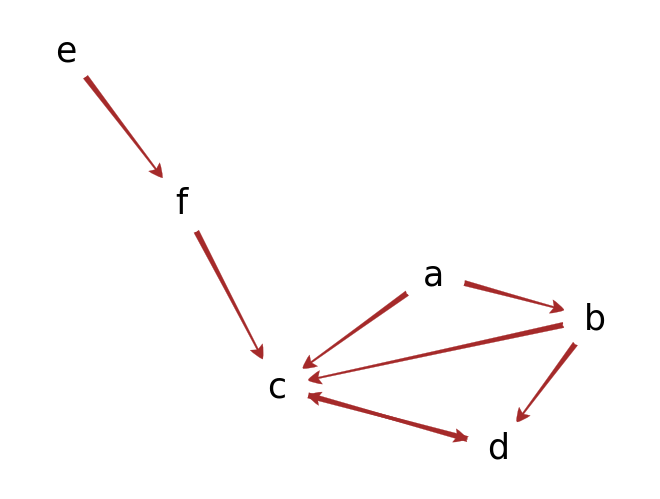

In [85]:
g.draw_graph()

**Graph Traversal**

*This is done by Breadth first search you can also do it by Depth first search* 


In [89]:
def traverse_graph(self, start):
    """Traverse graph starting from given start node."""
    
    q = [start]
    visited = []
    
    while q:
        current = q.pop(0)
        
        # if we've already visited it, we can skip 
        if current in visited:
            continue
        
        print(current)
        
        # we're done with current
        visited.append(current)
        
        # get all directly connected nodes
        next_nodes = self.g[current]
        
        # traverse all the nexts
        for n in next_nodes:
            q.append(n)
            
DiGraph.traverse_graph = traverse_graph

In [92]:
g.traverse_graph('a')       # also travrse from e

a
b
c
d


In [94]:
def find_path(self, start, end, path=[]):
    """Find path (not necessary shortest) from start to end."""
    # sanity check
    if start not in self.g:
        raise ValueError("Source node not in graph")
    
    # save the path we have traversed till now
    path = path + [start]
    
    # base case
    if start == end:
        return path
    
    # recursive case
    for node in self.g[start]:
        
        # need to avoid cycles
        if node not in path:
            
            # find path from next node to
            newpath = self.find_path(node, end, path)
            if newpath:
                return newpath
            
    # if no path can be found from any of the next nodes to the end, there's no path!
    return None
    
DiGraph.find_path = find_path

In [95]:
g.find_path('d', 'd')

['d']

In [97]:
g.find_path('a', 'a')

['a']

In [98]:
g.find_path('a', 'c')

['a', 'b', 'c']

In [100]:
print(g.find_path('a', 'f'))

None


# **Find All PAths Instead**

In [103]:
def find_all_paths(self, start, end, path=[]):
    """Find all possible paths (NOT necessary shortest) from start to end. """
    # sanity check
    if start not in self.g:
        raise ValueError("Source node not in graph")
    
    # save the path we have traversed till now
    path = path + [start]
    
    # base case
    if start == end:
        return [path]       # return the path in a list since we have many
    
    
    all_paths = []
    
    # recursive case
    for node in self.g[start]:
        
        # need to avoid cycles
        if node not in path:
            
            # find path from next node to
            all_newpaths = self.find_all_paths(node, end, path)
            for newpath in all_newpaths:
                all_paths.append(newpath)
                
    
    # if we path can be found from any of the next nodes to the end, there's no path!
    return all_paths

DiGraph.find_all_paths = find_all_paths

In [104]:
g.find_all_paths('a', 'd')

[['a', 'b', 'c', 'd'], ['a', 'b', 'd'], ['a', 'c', 'd']]

# **Shortest Path**

In [105]:
def find_shortest_path(self, start, end, path=[]):
    """Finding the shortest path from source to destination"""
    # sanity check
    if start not in self.g:
        raise ValueError("Source node not in graph")
    
    
    # save the path we have traversed till now
    path = path + [start]
    
    # base case
    if start == end:
        return path
    
    
    shortest = None     # change
    # recursive case
    for node in self.g[start]:
        
        # need to avoid cycles
        if node not in path:
            
            # find path from next node to
            newpath = self.find_shortest_path(node, end, path)
            if newpath:
                if shortest is None or len(newpath) < len(shortest):    # change
                    shortest = newpath
                    
    # if no path can be found from any of the next nodes to the end, there's no path!
    return shortest

DiGraph.find_shortest_path = find_shortest_path

In [106]:
g.find_shortest_path('a', 'd')

['a', 'b', 'd']

In [110]:
g.find_all_paths('a', 'd')

[['a', 'b', 'c', 'd'], ['a', 'b', 'd'], ['a', 'c', 'd']]